# Radar Signal Manipulation

This notebook introduces the radar signal step by step, using the real example `window_000000.npz`.
The goal is to start from the raw UWB CIR and progressively build a more interpretable representation.


In [1]:
# Install gdown for downloading files from Google Drive
!pip install gdown -q

In [2]:

# Construct the download URL
DOWNLOAD_URL = f'https://drive.google.com/uc?id=1a7sFoMi6qVKj7yaxZKMlU_BFX_SUxR2S'

# Define the target path for the downloaded file
OUTPUT_PATH = 'window_000000.npz'

print(f"Downloading file to: {OUTPUT_PATH}")

# Download the file using gdown
!gdown --id {FILE_ID} -O {OUTPUT_PATH}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id={FILE_ID}

but Gdown can't. Please check connections and permissions.


## 1. Radar context

The dataset uses **TrueSense TSRR-250** radar modules based on the **NXP SR250** UWB chip.

Each radar provides a **complex CIR** (Channel Impulse Response) measured over:

- **120 range bins**
- **3 receive antennas**
- **I/Q samples** in the last dimension

The complex CIR is reconstructed as:

$$
\mathrm{CIR}(t, r) = I(t, r) + jQ(t, r)
$$

A key conversion rule for this dataset is:

- **1 bin = 0.15 m = 15 cm**
- **120 bins = 18 m** of total physical range

The three RX antennas are arranged in an **L-shape**:

- `rx0` and `rx2` define the horizontal baseline
- `rx1` is placed on the vertical branch
- the spacing between adjacent RX antennas is **7.5 mm**

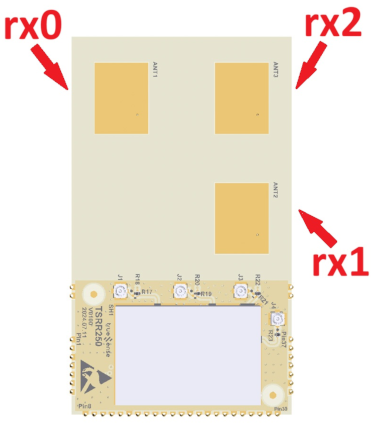

The radar **field of view is about 120°**, so roughly **±60° around boresight**.

During the acquisitions, six radars were placed around the room perimeter.
In this notebook we analyze **SR250_1**, whose position is:

- **x = 2.4 m**
- **y = 0.0 m**

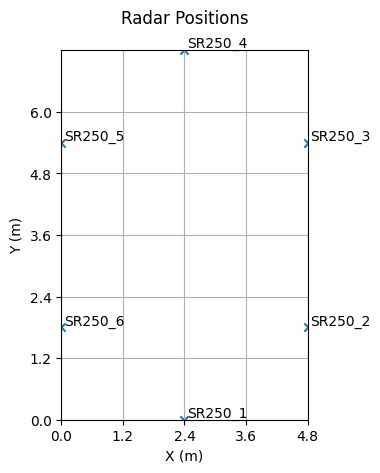

and whose boresight points toward **positive y**, that is, from the south wall into the room.

## 2. Load the dataset, split the fields, and create the complex CIR

We now load the `.npz` file and extract the four main arrays:

- `radar_cir_iq`
- `people_xy`
- `people_mask`
- `timestamps`

Then we reconstruct the complex radar signal from the I and Q channels.


In [3]:
import numpy as np

DATA_PATH = "window_000000.npz"

data = np.load(DATA_PATH)

radar_cir_iq = data["radar_cir_iq"]
people_xy = data["people_xy"]
people_mask = data["people_mask"]
timestamps = data["timestamps"]

cir_complex = radar_cir_iq[..., 0] + 1j * radar_cir_iq[..., 1]

print("Available keys:", data.files)
print("radar_cir_iq shape:", radar_cir_iq.shape)
print("people_xy shape   :", people_xy.shape)
print("people_mask shape :", people_mask.shape)
print("timestamps shape  :", timestamps.shape)
print("Complex CIR shape :", cir_complex.shape)


Available keys: ['radar_cir_iq', 'people_xy', 'people_mask', 'timestamps']
radar_cir_iq shape: (7500, 6, 3, 120, 2)
people_xy shape   : (7500, 4, 2)
people_mask shape : (7500, 4)
timestamps shape  : (7500,)
Complex CIR shape : (7500, 6, 3, 120)


## 3. Plot the raw data magnitude

We select one radar and one receiving antenna, and we display the **raw magnitude** of the signal.
This is the most immediate way to inspect the CIR as a time-range map.


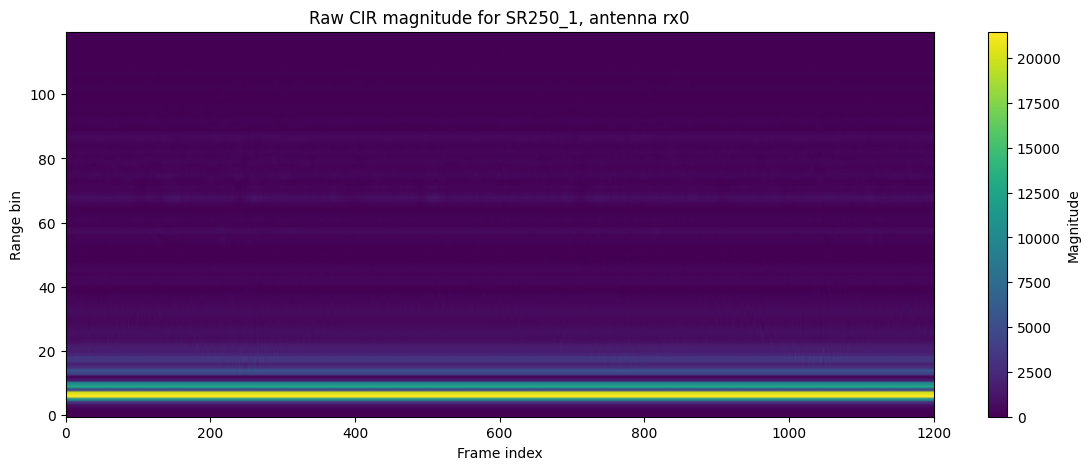

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["image.cmap"] = "viridis"

RADAR_IDX = 0      # SR250_1
ANTENNA_IDX = 0    # rx0
FRAME_LIMIT = 1200

radar_name = "SR250_1"
raw_signal = cir_complex[:, RADAR_IDX, ANTENNA_IDX, :]
raw_magnitude = np.abs(raw_signal)
raw_magnitude_plot = raw_magnitude[:FRAME_LIMIT]

plt.figure(figsize=(14, 5))
plt.imshow(raw_magnitude_plot.T, aspect="auto", origin="lower")
plt.colorbar(label="Magnitude")
plt.xlabel("Frame index")
plt.xlim(0, FRAME_LIMIT)
plt.ylabel("Range bin")
plt.title(f"Raw CIR magnitude for {radar_name}, antenna rx{ANTENNA_IDX}")
plt.show()


## 4. Declutter the data and plot the result with `alpha = 0.8`, without warmup

We now remove part of the static background using a simple exponential moving average:

$$
B_t = \alpha B_{t-1} + (1-\alpha)\,CIR_t
$$

and then:

$$
D_t = CIR_t - B_t
$$

Here we explicitly use `alpha = 0.8`


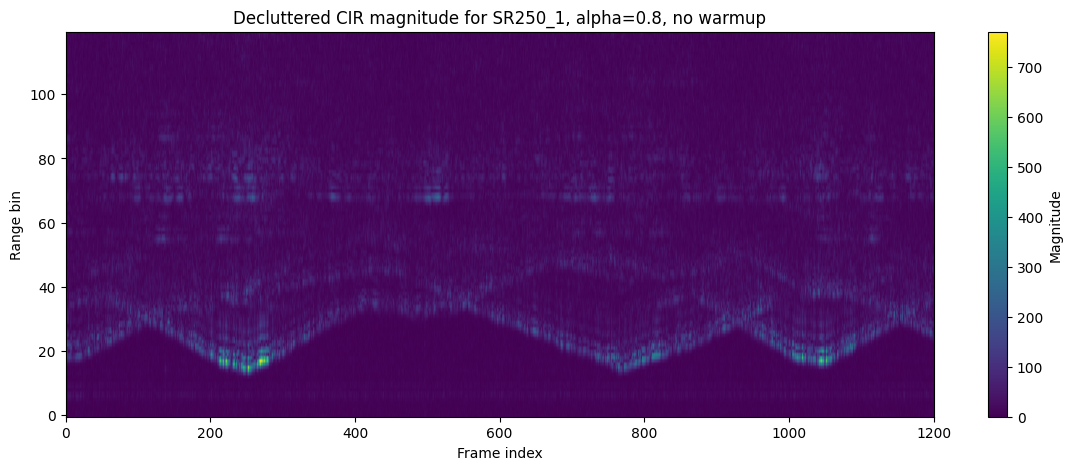

In [5]:
ALPHA = 0.8

background = raw_signal[0].astype(np.complex64).copy()
decluttered = np.empty_like(raw_signal, dtype=np.complex64)

for t in range(raw_signal.shape[0]):
    background = ALPHA * background + (1.0 - ALPHA) * raw_signal[t]
    decluttered[t] = raw_signal[t] - background

decluttered_magnitude = np.abs(decluttered)
decluttered_magnitude_plot = decluttered_magnitude[:FRAME_LIMIT]

plt.figure(figsize=(14, 5))
plt.imshow(decluttered_magnitude_plot.T, aspect="auto", origin="lower")
plt.colorbar(label="Magnitude")
plt.xlabel("Frame index")
plt.xlim(0, FRAME_LIMIT)
plt.ylabel("Range bin")
plt.title(f"Decluttered CIR magnitude for {radar_name}, alpha={ALPHA}, no warmup")
plt.show()


## 5. Plot the decluttered data using a physical range scale

Up to now the vertical axis has been expressed in **bins**.
Since in this dataset **1 bin = 15 cm**, we can convert the vertical axis into **meters**.
This makes the plot easier to interpret physically.


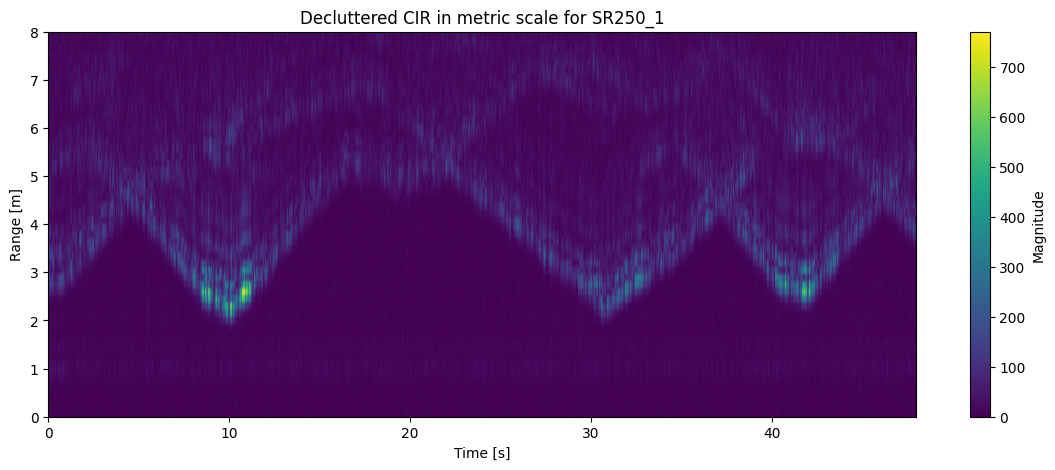

In [6]:
BIN_SIZE_M = 0.15
MAX_RANGE_M = 8.0
range_axis_m = np.arange(decluttered.shape[1]) * BIN_SIZE_M
time_axis_plot = timestamps[:FRAME_LIMIT]

plt.figure(figsize=(14, 5))
plt.imshow(
    decluttered_magnitude_plot.T,
    aspect="auto",
    origin="lower",
    extent=[time_axis_plot[0], time_axis_plot[-1], range_axis_m[0], range_axis_m[-1]],
)
plt.colorbar(label="Magnitude")
plt.xlabel("Time [s]")
plt.ylabel("Range [m]")
plt.ylim(0, MAX_RANGE_M)
plt.title(f"Decluttered CIR in metric scale for {radar_name}")
plt.show()


## 6. Overlay the person distance trace

We now superimpose the ground-truth person distance on the decluttered radar plot.
For this step we use the radar position explicitly:

- **x = 2.4 m**
- **y = 0.0 m**

For each active person, the distance from the radar is computed as:

$$
d(t) = \sqrt{(x_p(t)-2.4)^2 + (y_p(t)-0)^2}
$$


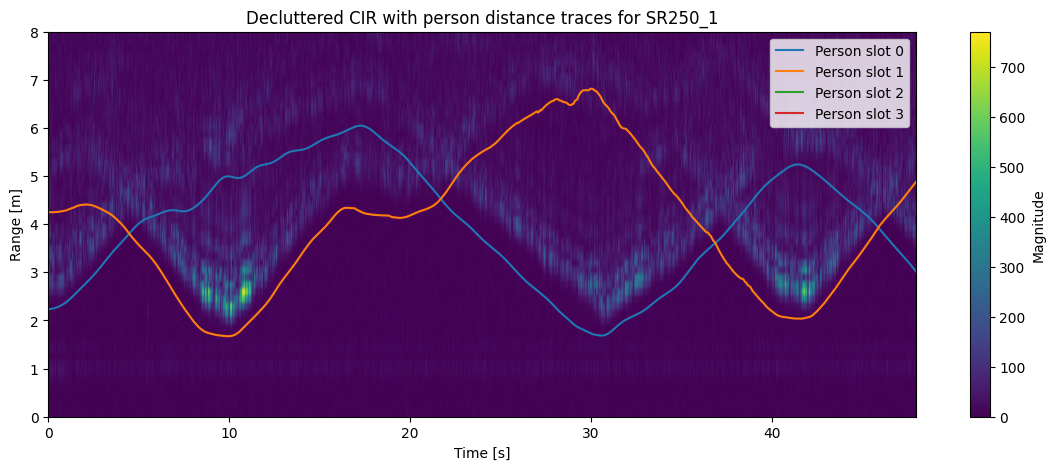

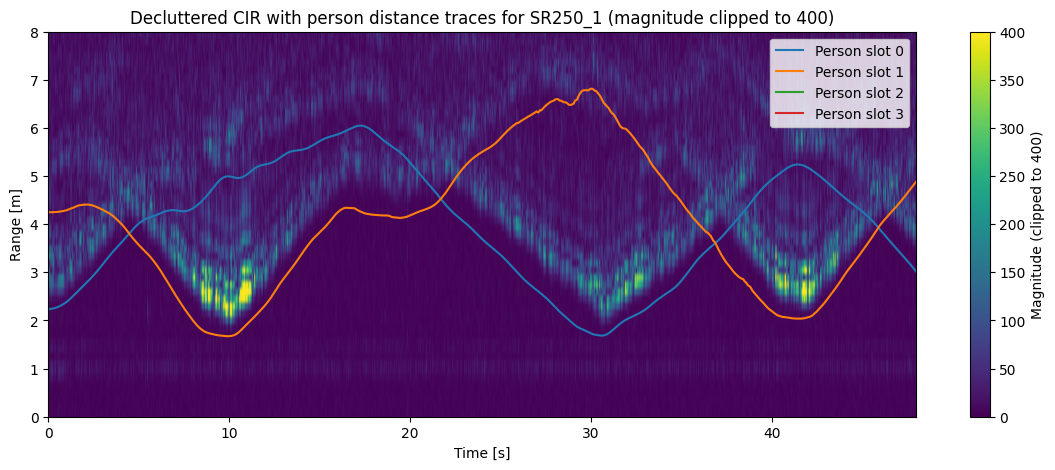

In [7]:
RADAR_X = 2.4
RADAR_Y = 0.0
radar_pos_xy = np.array([RADAR_X, RADAR_Y], dtype=np.float32)

num_frames, max_people = people_mask.shape
people_distance_m = np.full((num_frames, max_people), np.nan, dtype=np.float32)

for t in range(num_frames):
    valid = people_mask[t].astype(bool)
    if not np.any(valid):
        continue
    deltas = people_xy[t, valid] - radar_pos_xy
    distances = np.linalg.norm(deltas, axis=1)
    people_distance_m[t, np.where(valid)[0]] = distances

plt.figure(figsize=(14, 5))
people_distance_plot = people_distance_m[:FRAME_LIMIT].copy()
people_mask_plot = people_mask[:FRAME_LIMIT].copy()

plt.imshow(
    decluttered_magnitude_plot.T,
    aspect="auto",
    origin="lower",
    extent=[time_axis_plot[0], time_axis_plot[-1], range_axis_m[0], range_axis_m[-1]],
)

for person_idx in range(max_people):
    valid = people_mask_plot[:, person_idx].astype(bool)
    plt.plot(
        time_axis_plot[valid],
        people_distance_plot[valid, person_idx],
        linewidth=1.5,
        label=f"Person slot {person_idx}"
    )

plt.colorbar(label="Magnitude")
plt.xlabel("Time [s]")
plt.ylabel("Range [m]")
plt.ylim(0, MAX_RANGE_M)
plt.title(f"Decluttered CIR with person distance traces for {radar_name}")
plt.legend(loc="upper right")
plt.show()

MAGNITUDE_CLIP_MAX = 400
detail_time_axis = time_axis_plot.copy()
detail_decluttered_magnitude = np.clip(decluttered_magnitude_plot.copy(), 0, MAGNITUDE_CLIP_MAX)
detail_people_distance = people_distance_plot.copy()
detail_people_mask = people_mask_plot.copy()

plt.figure(figsize=(14, 5))
plt.imshow(
    detail_decluttered_magnitude.T,
    aspect="auto",
    origin="lower",
    extent=[detail_time_axis[0], detail_time_axis[-1], range_axis_m[0], range_axis_m[-1]],
)

for person_idx in range(max_people):
    valid = detail_people_mask[:, person_idx].astype(bool)
    plt.plot(
        detail_time_axis[valid],
        detail_people_distance[valid, person_idx],
        linewidth=1.5,
        label=f"Person slot {person_idx}"
    )

plt.colorbar(label=f"Magnitude (clipped to {MAGNITUDE_CLIP_MAX})")
plt.xlabel("Time [s]")
plt.ylabel("Range [m]")
plt.ylim(0, MAX_RANGE_M)
plt.title(f"Decluttered CIR with person distance traces for {radar_name} (magnitude clipped to {MAGNITUDE_CLIP_MAX})")
plt.legend(loc="upper right")
plt.show()


## 7. Apply the 5-bin offset for alignment

The last step is to remove the first **5 bins**.

This is useful when we want to align the plot with the convention that ignores the first near-range part of the signal.


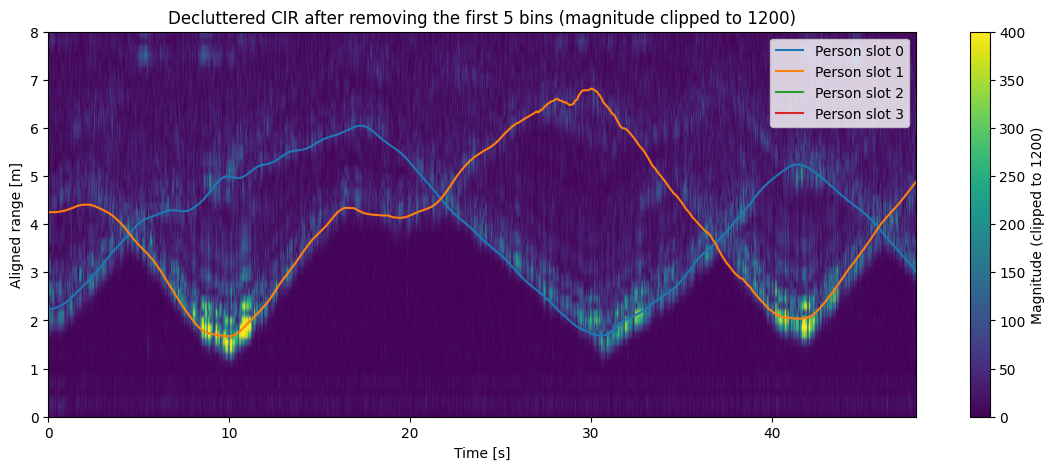

In [8]:
BIN_OFFSET = 5

offset_signal = decluttered[:FRAME_LIMIT, BIN_OFFSET:]
offset_magnitude = np.abs(offset_signal)
offset_magnitude_clipped = np.clip(offset_magnitude.copy(), 0, MAGNITUDE_CLIP_MAX)
offset_range_axis_m = np.arange(offset_signal.shape[1]) * BIN_SIZE_M

plt.figure(figsize=(14, 5))
plt.imshow(
    offset_magnitude_clipped.T,
    aspect="auto",
    origin="lower",
    extent=[time_axis_plot[0], time_axis_plot[-1], offset_range_axis_m[0], offset_range_axis_m[-1]],
)

for person_idx in range(max_people):
    valid = people_mask_plot[:, person_idx].astype(bool)
    plt.plot(
        time_axis_plot[valid],
        people_distance_plot[valid, person_idx],
        linewidth=1.5,
        label=f"Person slot {person_idx}"
    )

plt.colorbar(label="Magnitude (clipped to 1200)")
plt.xlabel("Time [s]")
plt.ylabel("Aligned range [m]")
plt.ylim(0, MAX_RANGE_M)
plt.title(f"Decluttered CIR after removing the first {BIN_OFFSET} bins (magnitude clipped to 1200)")
plt.legend(loc="upper right")
plt.show()
